In [1]:
!pip install transformers torch pandas scikit-learn matplotlib shap

In [2]:
# Colab 셀 2: Google Drive 마운트 및 기본 설정
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_recall_curve, f1_score

# 1. Google Drive 마운트
from google.colab import drive
drive.mount('/content/drive')

# 2. (중요!) 님의 Google Drive 경로로 수정하세요
# 예: /content/drive/MyDrive/KAMP_Project/
BASE_PATH = "/content/drive/MyDrive/KAMP_Battery_Project"

# 3. GPU 설정
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# 4. (중요!) 가이드북 기반 208개 센서 변수 정의
VOLTAGE_COLS = [f'M{m:02d}CV{c:02d}' for m in range(1, 17) for c in range(1, 12)]
TEMP_COLS = [f'M{m:02d}T{t:02d}' for m in range(1, 17) for t in range(1, 3)]
SENSOR_COLS = VOLTAGE_COLS + TEMP_COLS # 총 208개
print(f"선택된 센서 변수 개수: {len(SENSOR_COLS)}개")

Mounted at /content/drive
Using device: cuda
선택된 센서 변수 개수: 208개


In [3]:
# Colab 셀 3: 모델 아키텍처 정의
import torch
import torch.nn as nn
from transformers import DistilBertConfig, DistilBertModel

# 1. 트랜스포머(BERT) 설정을 정의합니다.
# ... (이하 동일) ...
from transformers import DistilBertConfig, DistilBertModel

# 1. 트랜스포머(BERT) 설정을 정의합니다.
#    208개 센서(토큰) 간의 관계를 학습하기 위한 설정입니다.
config = DistilBertConfig(
    vocab_size=1,  # 사용하지 않지만 필요
    max_position_embeddings=208,  # 센서의 개수 (우리의 '문장 길이')
    n_layers=4,       # 트랜스포머 레이어 수 (조절 가능)
    n_heads=4,        # 어텐션 헤드 수 (조절 가능)
    dim=128,          # 임베딩 차원 (조절 가능)
    hidden_dim=256    # 피드포워드 차원
)

class SensorTransformerAutoencoder(nn.Module):
    def __init__(self, num_sensors=208, d_model=128):
        super().__init__()

        self.num_sensors = num_sensors

        # --- 인코더 (Encoder) ---

        # 1. 입력 임베딩: (batch, 208) -> (batch, 208, 128)
        #    각 센서의 1개 값을 128차원 벡터로 변환합니다.
        self.input_embedding = nn.Linear(1, d_model)

        # 2. 위치 임베딩: 센서의 '순서'(M01CV01, M01CV02...)가 중요하므로 추가합니다.
        self.positional_embedding = nn.Embedding(num_sensors, d_model)

        # 3. 허깅페이스 트랜스포머(BERT) 인코더
        #    이 부분이 208개 센서 간의 관계를 학습합니다.
        #    사전 학습된 가중치를 로드하지 않고 구조만 사용합니다.
        self.transformer_encoder = DistilBertModel(config)


        # --- 디코더 (Decoder) ---

        # 4. 복원 레이어: (batch, 208, 128) -> (batch, 208)
        #    학습된 관계(128차원)를 다시 1개의 센서 값으로 복원합니다.
        self.decoder_head = nn.Linear(d_model, 1)

    def forward(self, x):
        # x의 입력 형태: (batch_size, 208)

        # 1. 임베딩 준비
        # (batch, 208) -> (batch, 208, 1)
        x_unsqueezed = x.unsqueeze(-1)
        # (batch, 208, 1) -> (batch, 208, 128)
        embedded_x = self.input_embedding(x_unsqueezed)

        # 2. 위치 임베딩 추가
        # (0, 1, 2, ..., 207)
        positions = torch.arange(0, self.num_sensors).expand(x.size(0), -1).to(DEVICE)
        pos_emb = self.positional_embedding(positions)

        final_embedding = embedded_x + pos_emb

        # 3. 트랜스포머 인코더 통과
        # (batch, 208, 128) -> (batch, 208, 128)
        # attention_mask=None이므로 모든 센서가 모든 센서를 참조합니다.
        encoder_output = self.transformer_encoder(inputs_embeds=final_embedding)
        hidden_state = encoder_output.last_hidden_state

        # 4. 디코더(복원)
        # (batch, 208, 128) -> (batch, 208, 1)
        reconstructed_x = self.decoder_head(hidden_state)

        # (batch, 208, 1) -> (batch, 208)
        return reconstructed_x.squeeze(-1)

print("✅ 'SensorTransformerAutoencoder' 모델이 정의되었습니다.")

✅ 'SensorTransformerAutoencoder' 모델이 정의되었습니다.


In [4]:
import torch
from torch.utils.data import Dataset

class BatteryDataset(Dataset):

    def __init__(self, data):

        self.data = torch.FloatTensor(data)



    def __len__(self):

        return len(self.data)



    def __getitem__(self, idx):

        return self.data[idx]

In [ ]:
# --- (필수) 1. 모든 import ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler # (수정!) MinMaxScaler -> StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer # (신규!) 결측치 대체
from transformers import DistilBertConfig, DistilBertModel

# --- (필수) 2. 기본 변수 정의 ---
# 님의 로컬 경로
BASE_PATH = "/content/drive/MyDrive/KAMP_Battery_Project/raw_data/train"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# 1000~1050 파일 리스트
TRAIN_FILES = []
for i in range(1000, 1051):
    TRAIN_FILES.append(f'{i}_chg.csv')
    TRAIN_FILES.append(f'{i}_dchg.csv')

# [cite_start]208개 센서 변수 정의 [cite: 1378-1379]
VOLTAGE_COLS = [f'M{m:02d}CV{c:02d}' for m in range(1, 17) for c in range(1, 12)]
TEMP_COLS = [f'M{m:02d}T{t:02d}' for m in range(1, 17) for t in range(1, 3)]
SENSOR_COLS = VOLTAGE_COLS + TEMP_COLS
print(f"선택된 센서 변수 개수: {len(SENSOR_COLS)}개")

# --- (필수) 3. 모델 아키텍처 정의 ---
config = DistilBertConfig(
    vocab_size=1, max_position_embeddings=208,
    n_layers=4, n_heads=4, dim=128, hidden_dim=256
)
class SensorTransformerAutoencoder(nn.Module):
    def __init__(self, num_sensors, d_model=128):
        super().__init__()
        self.num_sensors = num_sensors
        self.input_embedding = nn.Linear(1, d_model)
        self.positional_embedding = nn.Embedding(self.num_sensors, d_model)
        self.transformer_encoder = DistilBertModel(config)
        self.decoder_head = nn.Linear(d_model, 1)

    def forward(self, x):
        x_unsqueezed = x.unsqueeze(-1)
        embedded_x = self.input_embedding(x_unsqueezed)
        positions = torch.arange(0, self.num_sensors).expand(x.size(0), -1).to(DEVICE)
        pos_emb = self.positional_embedding(positions)
        final_embedding = embedded_x + pos_emb

        padding_size = 208 - self.num_sensors
        attention_mask = torch.ones(x.size(0), self.num_sensors).to(DEVICE)

        if padding_size > 0:
            pad = torch.zeros(final_embedding.size(0), padding_size, final_embedding.size(2)).to(DEVICE)
            final_embedding = torch.cat([final_embedding, pad], dim=1)
            pad_mask = torch.zeros(x.size(0), padding_size).to(DEVICE)
            attention_mask = torch.cat([attention_mask, pad_mask], dim=1)

        encoder_output = self.transformer_encoder(inputs_embeds=final_embedding, attention_mask=attention_mask)
        hidden_state = encoder_output.last_hidden_state
        hidden_state = hidden_state[:, :self.num_sensors, :]
        reconstructed_x = self.decoder_head(hidden_state)
        return reconstructed_x.squeeze(-1)
print("✅ 'SensorTransformerAutoencoder' 모델이 정의되었습니다.")

# --- (필수) 4. 데이터셋 클래스 정의 ---
class BatteryDataset(Dataset):
    def __init__(self, data):
        self.data = torch.FloatTensor(data)
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]
print("✅ 'BatteryDataset' 클래스가 정의되었습니다.")

# --- 5. 학습 설정 ---
BATCH_SIZE = 64
NUM_EPOCHS = 100
LEARNING_RATE = 1e-5 # 'nan' 방지를 위해 낮게 설정
VALIDATION_SPLIT = 0.3
PATIENCE = 5
CLIP_VALUE = 1.0 # 그래디언트 클리핑
best_val_loss = float('inf')
epochs_no_improve = 0

# --- 6. 학습 데이터 로드 및 "3중 방어" 전처리 ---
print(f"학습 데이터 로딩 중 (102개 파일) from: {BASE_PATH}")
all_train_df = []
for f in TRAIN_FILES:
    try:
        # 'train' 폴더가 없는 올바른 경로
        file_path = os.path.join(BASE_PATH, f)

        df = pd.read_csv(file_path, dtype=object)
        df = df[SENSOR_COLS]
        all_train_df.append(df)
    except FileNotFoundError:
        print(f"경고: {file_path} 파일을 찾을 수 없습니다. 건너뜁니다.")
    except Exception as e:
        print(f"오류: {f} 파일 로드 중 문제 발생. {e}")

if not all_train_df:
    raise ValueError("로드된 학습 데이터 파일이 없습니다. BASE_PATH와 TRAIN_FILES를 확인하세요.")

train_data_full = pd.concat(all_train_df, ignore_index=True)

# (신규 1) 숫자로 변환 (변환 안되는 값은 nan으로 강제)
train_data_full = train_data_full.apply(pd.to_numeric, errors='coerce')
print(f"총 {len(train_data_full)}개 타임스탬프 로드 및 숫자 변환 완료.")

# (신규 2) 'inf' (무한대) 값 -> 'nan'으로 변경
train_data_full.replace([np.inf, -np.inf], np.nan, inplace=True)
print("✅ 무한대(inf) 값을 'nan'으로 대체했습니다.")

# (신규 3) 'nan' (결측치) 값 -> '0.0'으로 대체 (가장 중요!)
imputer = SimpleImputer(strategy='constant', fill_value=0.0)
train_data_imputed = imputer.fit_transform(train_data_full)
train_data_full = pd.DataFrame(train_data_imputed, columns=SENSOR_COLS)
print("✅ 모든 'nan' 값을 0.0으로 대체했습니다.")

# (신규 4) '상수' 센서 제거 (정밀 검사)
sensor_stats = train_data_full.describe().transpose()
# (수정!) 표준편차(std)가 1e-9 (거의 0) 이하인 센서를 모두 찾음
constant_sensors = sensor_stats[sensor_stats['std'] < 1e-9].index.tolist()

if len(constant_sensors) > 0:
    print(f"\n--- ⚠️ 'nan' 유발 상수 센서 {len(constant_sensors)}개 발견! ---")
    print(f"제외되는 센서: {constant_sensors}")
else:
    print("\n--- ✅ 'nan' 유발 상수 센서 없음 ---")

final_sensor_cols = [col for col in SENSOR_COLS if col not in constant_sensors]
NUM_FINAL_SENSORS = len(final_sensor_cols)
print(f"총 208개 센서 중 {NUM_FINAL_SENSORS}개의 '정상' 센서로 학습을 시작합니다.")

FINAL_COLS_SAVE_PATH = os.path.join(BASE_PATH, "final_sensor_cols.pkl")
with open(FINAL_COLS_SAVE_PATH, 'wb') as f:
    pickle.dump(final_sensor_cols, f)
print(f"'최종 센서 리스트'가 {FINAL_COLS_SAVE_PATH}에 저장되었습니다.")

# --- 7. 스케일링 및 데이터 분리 ---
train_data_filtered = train_data_full[final_sensor_cols]

# (수정!) StandardScaler로 변경
scaler = StandardScaler()
train_data_scaled = scaler.fit_transform(train_data_filtered)
print("✅ StandardScaler 적용 완료.")

SCALER_SAVE_PATH = os.path.join(BASE_PATH, "transformer_scaler.pkl")
with open(SCALER_SAVE_PATH, 'wb') as f:
    pickle.dump(scaler, f)
print(f"스케일러(StandardScaler)가 {SCALER_SAVE_PATH}에 저장되었습니다.")

train_data, val_data = train_test_split(train_data_scaled, test_size=VALIDATION_SPLIT, random_state=42)
print(f"학습용 데이터: {len(train_data)}개, 검증용 데이터: {len(val_data)}개")

train_dataset = BatteryDataset(train_data)
val_dataset = BatteryDataset(val_data)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- 8. 모델 및 옵티마이저 설정 ---
model = SensorTransformerAutoencoder(num_sensors=NUM_FINAL_SENSORS).to(DEVICE)
loss_fn = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)
MODEL_SAVE_PATH = os.path.join(BASE_PATH, "transformer_autoencoder.pth")

print("--- 학습 시작 ---")
# --- 9. 학습 루프 ---
for epoch in range(NUM_EPOCHS):
    model.train()
    total_train_loss = 0
    for batch_data in train_loader:
        batch_data = batch_data.to(DEVICE)
        reconstructed = model(batch_data)
        loss = loss_fn(reconstructed, batch_data)

        if torch.isnan(loss):
            print(f"❌ Epoch {epoch+1} - 손실(Loss)이 'nan'입니다. 학습을 중단합니다.")
            break

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_VALUE)
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    if torch.isnan(torch.tensor(avg_train_loss)):
        print(f"❌ Epoch {epoch+1} - 평균 손실(Loss)이 'nan'입니다. 학습을 중단합니다.")
        break # 전체 학습 루프 중단

    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch_data in val_loader:
            batch_data = batch_data.to(DEVICE)
            reconstructed = model(batch_data)
            loss = loss_fn(reconstructed, batch_data)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

    scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"  -> Val Loss 개선됨. 모델 저장. ({MODEL_SAVE_PATH})")
    else:
        epochs_no_improve += 1
        print(f"  -> Val Loss 개선 없음. (Patience: {epochs_no_improve}/{PATIENCE})")

    if epochs_no_improve >= PATIENCE:
        print(f"\n--- 조기 종료: {PATIENCE} Epoch 동안 Val Loss가 개선되지 않았습니다. ---")
        break

print("--- 학습 완료 ---")
if not torch.isnan(torch.tensor(avg_train_loss)):
    print(f"가장 좋았던 모델(Val Loss: {best_val_loss:.6f})이 저장되었습니다.")
else:
    print("학습이 'nan' 값으로 인해 비정상적으로 중단되었습니다. (모델 저장 안 됨)")

Using device: cuda
선택된 센서 변수 개수: 208개
✅ 'SensorTransformerAutoencoder' 모델이 정의되었습니다.
✅ 'BatteryDataset' 클래스가 정의되었습니다.
학습 데이터 로딩 중 (102개 파일) from: /content/drive/MyDrive/KAMP_Battery_Project/raw_data/train
총 482639개 타임스탬프 로드 및 숫자 변환 완료.
✅ 무한대(inf) 값을 'nan'으로 대체했습니다.
✅ 모든 'nan' 값을 0.0으로 대체했습니다.

--- ✅ 'nan' 유발 상수 센서 없음 ---
총 208개 센서 중 208개의 '정상' 센서로 학습을 시작합니다.
'최종 센서 리스트'가 /content/drive/MyDrive/KAMP_Battery_Project/raw_data/train/final_sensor_cols.pkl에 저장되었습니다.
✅ StandardScaler 적용 완료.
스케일러(StandardScaler)가 /content/drive/MyDrive/KAMP_Battery_Project/raw_data/train/transformer_scaler.pkl에 저장되었습니다.
학습용 데이터: 337847개, 검증용 데이터: 144792개
--- 학습 시작 ---
Epoch 01/100 | Train Loss: 0.149304 | Val Loss: 0.043112
  -> Val Loss 개선됨. 모델 저장. (/content/drive/MyDrive/KAMP_Battery_Project/raw_data/train/transformer_autoencoder.pth)
Epoch 02/100 | Train Loss: 0.021386 | Val Loss: 0.006520
  -> Val Loss 개선됨. 모델 저장. (/content/drive/MyDrive/KAMP_Battery_Project/raw_data/train/transformer_autoencoder.pth)
Epoch

In [ ]:
# Colab 셀 5.5: (신규) Imputer 생성 및 저장 전용 셀

print("--- Imputer 재생성 시작 ---")
# --- (필수) 1. 모든 import ---
import pandas as pd
import numpy as np
import pickle
import os
from sklearn.impute import SimpleImputer

# --- (필수) 2. 기본 변수 정의 ---
BASE_PATH = "/content/drive/MyDrive/KAMP_Battery_Project"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TRAIN_FILES = []
for i in range(1000, 1051):
    TRAIN_FILES.append(f'{i}_chg.csv')
    TRAIN_FILES.append(f'{i}_dchg.csv')

VOLTAGE_COLS = [f'M{m:02d}CV{c:02d}' for m in range(1, 17) for c in range(1, 12)]
TEMP_COLS = [f'M{m:02d}T{t:02d}' for m in range(1, 17) for t in range(1, 3)]
SENSOR_COLS = VOLTAGE_COLS + TEMP_COLS
print(f"센서 변수 {len(SENSOR_COLS)}개 정의 완료.")

# --- 3. 102개 파일 로드 및 Imputer 학습/저장 ---
print(f"학습 데이터 로딩 중 (102개 파일) from: {BASE_PATH}/raw_data/train/")
all_train_df = []
for f in TRAIN_FILES:
    try:
        file_path = os.path.join(BASE_PATH, "raw_data", "train", f)
        df = pd.read_csv(file_path, dtype=object)
        df = df[SENSOR_COLS]
        all_train_df.append(df)
    except FileNotFoundError:
        print(f"경고: {file_path} 파일을 찾을 수 없습니다. 건너뜁니다.")
    except Exception as e:
        print(f"오류: {f} 파일 로드 중 문제 발생. {e}")

if not all_train_df:
    raise ValueError("로드된 학습 데이터 파일이 없습니다. 경로를 확인하세요.")

train_data_full = pd.concat(all_train_df, ignore_index=True)

# (1) 숫자로 변환
train_data_full = train_data_full.apply(pd.to_numeric, errors='coerce')
print(f"총 {len(train_data_full)}개 타임스탬프 로드 및 숫자 변환 완료.")

# (2) 'inf' -> 'nan'
train_data_full.replace([np.inf, -np.inf], np.nan, inplace=True)
print("✅ 무한대(inf) 값을 'nan'으로 대체했습니다.")

# (3) 'nan' -> '0.0' (Imputer 생성 및 학습)
# (중요!) 모델을 학습시키는 것이 아니라, Imputer만 '학습(fit)'시킵니다.
imputer = SimpleImputer(strategy='constant', fill_value=0.0)
imputer.fit(train_data_full)
print("✅ Imputer가 'nan' 값을 0.0으로 대체하도록 학습되었습니다.")

# (4) Imputer 저장
IMPUTER_SAVE_PATH = os.path.join(BASE_PATH, "raw_data/train", "imputer.pkl")
with open(IMPUTER_SAVE_PATH, 'wb') as f:
    pickle.dump(imputer, f)
print(f"✅ Imputer가 {IMPUTER_SAVE_PATH}에 성공적으로 저장되었습니다.")
print("\n--- Imputer 재생성 완료 ---")
print("이제 Colab 셀 6 (평가 셀)을 실행하셔도 됩니다.")

--- Imputer 재생성 시작 ---
센서 변수 208개 정의 완료.
학습 데이터 로딩 중 (102개 파일) from: /content/drive/MyDrive/KAMP_Battery_Project/raw_data/train/
총 482639개 타임스탬프 로드 및 숫자 변환 완료.
✅ 무한대(inf) 값을 'nan'으로 대체했습니다.
✅ Imputer가 'nan' 값을 0.0으로 대체하도록 학습되었습니다.
✅ Imputer가 /content/drive/MyDrive/KAMP_Battery_Project/raw_data/train/imputer.pkl에 성공적으로 저장되었습니다.

--- Imputer 재생성 완료 ---
이제 Colab 셀 6 (평가 셀)을 실행하셔도 됩니다.


Using device: cuda
✅ 모든 모델, 스케일러, Imputer, 센서 리스트 로드 완료.
분석할 NG 데이터 파일 검색 중 (Test01 ~ Test09)...

총 5개의 NG 파일을 찾았습니다:
 - Test05_NG_chg
 - Test06_NG_chg
 - Test07_NG_dchg
 - Test08_NG_chg
 - Test09_NG_dchg
SHAP 배경 데이터(정상 샘플) 로딩...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


SHAP 배경 데이터(K-Means 요약) shape: (10, 208)
SHAP Explainer가 준비되었습니다.

--- 🔬 F-score 및 글로벌 SHAP 분석 시작 ---

--- 파일 분석 중: Test05_NG_chg.csv ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


  -> Test05_NG_chg F1-Score: 0.9851
  -> Test05_NG_chg의 상위 5개 불량 샘플에 대해 SHAP 값 계산 중...


  0%|          | 0/5 [00:00<?, ?it/s]


--- 파일 분석 중: Test06_NG_chg.csv ---
  -> Test06_NG_chg F1-Score: 1.0000
  -> Test06_NG_chg의 상위 5개 불량 샘플에 대해 SHAP 값 계산 중...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


  0%|          | 0/5 [00:00<?, ?it/s]


--- 파일 분석 중: Test07_NG_dchg.csv ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


  -> Test07_NG_dchg F1-Score: 0.9956
  -> Test07_NG_dchg의 상위 5개 불량 샘플에 대해 SHAP 값 계산 중...


  0%|          | 0/5 [00:00<?, ?it/s]


--- 파일 분석 중: Test08_NG_chg.csv ---
  -> Test08_NG_chg F1-Score: 1.0000
  -> Test08_NG_chg의 상위 5개 불량 샘플에 대해 SHAP 값 계산 중...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


  0%|          | 0/5 [00:00<?, ?it/s]


--- 파일 분석 중: Test09_NG_dchg.csv ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


  -> Test09_NG_dchg F1-Score: 1.0000
  -> Test09_NG_dchg의 상위 5개 불량 샘플에 대해 SHAP 값 계산 중...


  0%|          | 0/5 [00:00<?, ?it/s]


--- 모든 SHAP 값 계산 완료 ---
--- 🔬 글로벌 SHAP 요약 플롯 (핵심 원인 센서) 🔬 ---
이 플롯은 모든 불량 파일에서 공통적으로 '이상 점수'에
가장 큰 영향을 미친 센서(변수)를 순서대로 보여줍니다.


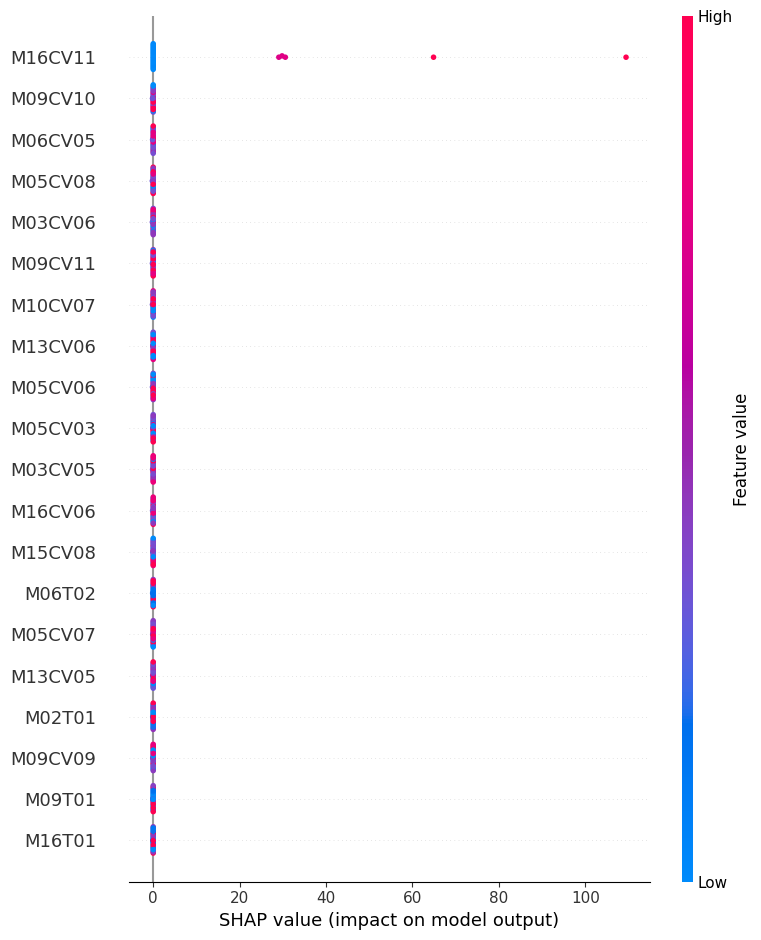

In [6]:
# Colab 셀 7: (최종) 글로벌 F-score 및 SHAP 요약 플롯

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score
from sklearn.impute import SimpleImputer

import shap
shap.initjs()

# --- 0. (필수) 기본 변수 정의 ---
# (이전 셀들과 동일한 정의를 사용)
BASE_PATH = "/content/drive/MyDrive/KAMP_Battery_Project"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# (BatteryDataset, SensorTransformerAutoencoder 클래스 정의가 이전에 실행되어 있어야 함)

# --- 1. 학습된 객체들 로드 ---
MODEL_SAVE_PATH = os.path.join(BASE_PATH, "raw_data/train", "transformer_autoencoder.pth")
SCALER_SAVE_PATH = os.path.join(BASE_PATH, "raw_data/train", "transformer_scaler.pkl")
FINAL_COLS_SAVE_PATH = os.path.join(BASE_PATH, "raw_data/train", "final_sensor_cols.pkl")
IMPUTER_SAVE_PATH = os.path.join(BASE_PATH, "raw_data/train", "imputer.pkl")

with open(FINAL_COLS_SAVE_PATH, 'rb') as f:
    FINAL_SENSOR_COLS = pickle.load(f)
NUM_FINAL_SENSORS = len(FINAL_SENSOR_COLS)

model = SensorTransformerAutoencoder(num_sensors=NUM_FINAL_SENSORS).to(DEVICE)
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.eval()

with open(SCALER_SAVE_PATH, 'rb') as f:
    scaler = pickle.load(f)

with open(IMPUTER_SAVE_PATH, 'rb') as f:
    imputer = pickle.load(f)
print("✅ 모든 모델, 스케일러, Imputer, 센서 리스트 로드 완료.")

# --- 2. (신규) 분석할 모든 NG 파일 리스트 정의 ---
# [cite_start](가이드북 [cite: 1012, 2398, 2511] 및 님께서 가진 파일을 기반으로 리스트 작성)
# (경로가 정확한지 확인하세요)
NG_FILES_TO_ANALYZE = {}

print("분석할 NG 데이터 파일 검색 중 (Test01 ~ Test09)...")

# 1번부터 9번까지 반복
for i in range(1, 10):
    num_str = f"{i:02d}" # 01, 02, ..., 09

    # 각 번호마다 'chg'(충전)와 'dchg'(방전) 두 가지 케이스가 있을 수 있으므로 모두 확인
    for type_str in ['chg', 'dchg']:
        # 예상되는 파일 이름 생성
        file_name = f"Test{num_str}_NG_{type_str}.csv"
        label_name = f"Test{num_str}_NG_{type_str}_Label.csv"

        # 전체 경로 생성
        data_path = os.path.join(BASE_PATH, "raw_data", "test", file_name)
        label_path = os.path.join(BASE_PATH, "preprocessed", "test", label_name)

        # (핵심!) 해당 데이터 파일이 실제로 존재할 때만 리스트에 추가
        if os.path.exists(data_path):
            key_name = f"Test{num_str}_NG_{type_str}"

            # 라벨 파일도 있는지 확인 (안전장치)
            if os.path.exists(label_path):
                NG_FILES_TO_ANALYZE[key_name] = {
                    'data': data_path,
                    'label': label_path
                }
            else:
                print(f"⚠️ 경고: 데이터는 있지만 라벨 파일이 없습니다: {label_name}")

# 검색된 파일 목록 출력
print(f"\n총 {len(NG_FILES_TO_ANALYZE)}개의 NG 파일을 찾았습니다:")
for key in NG_FILES_TO_ANALYZE:
    print(f" - {key}")

# --- 3. (신규) SHAP Explainer 준비 (배경 데이터) ---
# (메모리 OOM 방지를 위해 K-Means 10개 샘플 사용)
print("SHAP 배경 데이터(정상 샘플) 로딩...")
bg_df = pd.read_csv(os.path.join(BASE_PATH, "raw_data", "train", "1000_chg.csv"))
bg_data = bg_df[FINAL_SENSOR_COLS]
bg_imputed = imputer.transform(bg_data)
bg_scaled = scaler.transform(bg_imputed)
background_data = shap.kmeans(bg_scaled, 10)
print(f"SHAP 배경 데이터(K-Means 요약) shape: {background_data.data.shape}")

# SHAP 래퍼 함수 (모델의 '이상 점수' 계산)
def get_anomaly_score_for_shap(numpy_data):
    tensor_data = torch.FloatTensor(numpy_data).to(DEVICE)
    with torch.no_grad():
        reconstructed = model(tensor_data)
    errors = torch.mean((reconstructed - tensor_data)**2, dim=1)
    return errors.cpu().numpy()

explainer = shap.KernelExplainer(get_anomaly_score_for_shap, background_data)
print("SHAP Explainer가 준비되었습니다.")

# --- 4. (신규) 모든 NG 파일 순회 및 SHAP 값 누적 ---
all_shap_values = []
all_shap_data = []

print("\n--- 🔬 F-score 및 글로벌 SHAP 분석 시작 ---")
for file_name, paths in NG_FILES_TO_ANALYZE.items():
    print(f"\n--- 파일 분석 중: {file_name}.csv ---")

    # 1. 데이터 로드 및 전처리
    try:
        test_ng_df = pd.read_csv(paths['data'])
        label_df = pd.read_csv(paths['label'])
    except FileNotFoundError as e:
        print(f"경고: 파일을 찾을 수 없습니다. {e}. 이 파일을 건너뜁니다.")
        continue

    test_ng_data_filtered = test_ng_df[FINAL_SENSOR_COLS]
    test_ng_imputed = imputer.transform(test_ng_data_filtered)
    test_ng_scaled = scaler.transform(test_ng_imputed)
    true_labels = label_df['label'].values[:len(test_ng_scaled)]

    # 2. F-score 계산
    anomaly_scores = get_anomaly_score_for_shap(test_ng_scaled)
    precision, recall, thresholds = precision_recall_curve(true_labels, anomaly_scores)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
    best_f1 = np.max(f1_scores)
    print(f"  -> {file_name} F1-Score: {best_f1:.4f}")

    # 3. SHAP 분석을 위한 샘플 추출 (상위 5개)
    # (메모리 효율을 위해, '가장 확실한 불량' 5개만 샘플링)
    top_5_anomaly_indices = np.argsort(anomaly_scores)[-5:] # 이상 점수가 가장 높은 5개 인덱스
    samples_to_explain = test_ng_scaled[top_5_anomaly_indices]

    print(f"  -> {file_name}의 상위 5개 불량 샘플에 대해 SHAP 값 계산 중...")

    # 4. SHAP 값 계산 및 누적
    # (경고: 이 부분은 파일당 몇 분 정도 소요될 수 있습니다)
    shap_values = explainer.shap_values(samples_to_explain)

    all_shap_values.append(shap_values)
    all_shap_data.append(samples_to_explain)

print("\n--- 모든 SHAP 값 계산 완료 ---")

# --- 5. (신규) 글로벌 SHAP 요약 플롯 (최종 결과) ---
# (모든 파일에서 수집된 SHAP 값을 하나로 합침)
final_shap_values = np.concatenate(all_shap_values, axis=0)
final_shap_data = np.concatenate(all_shap_data, axis=0)

print("--- 🔬 글로벌 SHAP 요약 플롯 (핵심 원인 센서) 🔬 ---")
print("이 플롯은 모든 불량 파일에서 공통적으로 '이상 점수'에")
print("가장 큰 영향을 미친 센서(변수)를 순서대로 보여줍니다.")

# shap.summary_plot은 '상관관계가 높은 인자'를 완벽하게 시각화해 줍니다.
shap.summary_plot(
    final_shap_values,
    final_shap_data,
    feature_names=FINAL_SENSOR_COLS,
    max_display=20 # 상위 20개의 핵심 센서만 표시
)

Using device: cuda
--- 🚀 통합 분석 및 상관계수 도출 시작 ---
✅ 모델 및 전처리 객체 로드 완료.
총 5개의 NG 파일 세트를 찾았습니다.

📢 파일별 상세 성능 평가 (TP/TN/FP/FN Analysis)

[1/5] 분석 중: Test05_NG_chg.csv ...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


  ✅ Optimal Threshold: 0.000553
  [Confusion Matrix] TP:4206 | TN:683 | FP:74 | FN:53
  📊 Acc: 0.9747 | Prec: 0.9827 | Rec: 0.9876 | F1: 0.9851

[2/5] 분석 중: Test06_NG_chg.csv ...
  ✅ Optimal Threshold: 4.581685
  [Confusion Matrix] TP:854 | TN:0 | FP:0 | FN:0
  📊 Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000

[3/5] 분석 중: Test07_NG_dchg.csv ...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


  ✅ Optimal Threshold: 0.000625
  [Confusion Matrix] TP:225 | TN:4367 | FP:0 | FN:2
  📊 Acc: 0.9996 | Prec: 1.0000 | Rec: 0.9912 | F1: 0.9956

[4/5] 분석 중: Test08_NG_chg.csv ...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


  ✅ Optimal Threshold: 0.000686
  [Confusion Matrix] TP:2396 | TN:0 | FP:0 | FN:0
  📊 Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000

[5/5] 분석 중: Test09_NG_dchg.csv ...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


  ✅ Optimal Threshold: 0.000277
  [Confusion Matrix] TP:4864 | TN:0 | FP:0 | FN:0
  📊 Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000

🏆 전체 파일 성능 평가 요약
              File  F1-Score  Precision   Recall
 Test05_NG_chg.csv  0.985127    0.98271 0.987556
 Test06_NG_chg.csv  1.000000    1.00000 1.000000
Test07_NG_dchg.csv  0.995575    1.00000 0.991189
 Test08_NG_chg.csv  1.000000    1.00000 1.000000
Test09_NG_dchg.csv  1.000000    1.00000 1.000000
------------------------------------------------------------
✨ 전체 평균 F1-Score: 0.9961

🔬 글로벌 불량 원인 분석 (Global SHAP & Correlation)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


총 25개의 핵심 불량 샘플 분석 중...


  0%|          | 0/25 [00:00<?, ?it/s]


📊 센서 값과 불량 기여도(SHAP) 간의 상관계수 계산 중...

--- 🏆 불량 유발 핵심 센서 Top 10 (상관계수) ---
 Sensor  Defect_Correlation
M16CV11            0.954878
 M06T01            0.882328
M02CV01           -0.708708
M05CV10            0.599387
M01CV05           -0.436834
M13CV07           -0.429287
M09CV07            0.418777
M01CV02            0.413972
M14CV11            0.413234
M07CV11            0.410776

✅ 상관계수 분석 결과 저장 완료: /content/drive/MyDrive/KAMP_Battery_Project/sensor_defect_correlation_all.csv


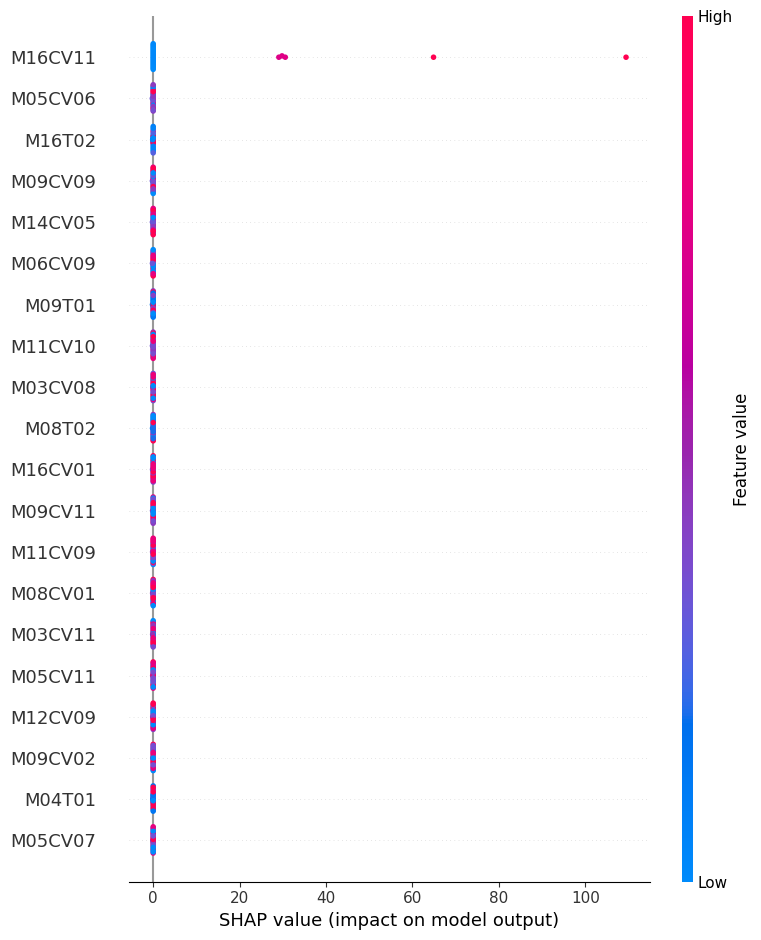

In [18]:
# Colab 셀 6: (최종 통합) 성능 평가 + SHAP 시각화 + 상관계수 저장

import torch
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score, confusion_matrix, accuracy_score, precision_score, recall_score
from torch.utils.data import DataLoader, Dataset
from sklearn.impute import SimpleImputer
from scipy.stats import pearsonr # (신규) 상관계수 계산용
import shap
shap.initjs()

# --- 0. (필수) 기본 설정 ---
BASE_PATH = "/content/drive/MyDrive/KAMP_Battery_Project"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

print("--- 🚀 통합 분석 및 상관계수 도출 시작 ---")

# --- 1. 학습된 객체들 로드 ---
MODEL_SAVE_PATH = os.path.join(BASE_PATH, "raw_data/train", "transformer_autoencoder.pth")
SCALER_SAVE_PATH = os.path.join(BASE_PATH, "raw_data/train", "transformer_scaler.pkl")
FINAL_COLS_SAVE_PATH = os.path.join(BASE_PATH, "raw_data/train", "final_sensor_cols.pkl")
IMPUTER_SAVE_PATH = os.path.join(BASE_PATH, "raw_data/train", "imputer.pkl")

with open(FINAL_COLS_SAVE_PATH, 'rb') as f:
    FINAL_SENSOR_COLS = pickle.load(f)
NUM_FINAL_SENSORS = len(FINAL_SENSOR_COLS)

model = SensorTransformerAutoencoder(num_sensors=NUM_FINAL_SENSORS).to(DEVICE)
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.eval()

with open(SCALER_SAVE_PATH, 'rb') as f:
    scaler = pickle.load(f)

with open(IMPUTER_SAVE_PATH, 'rb') as f:
    imputer = pickle.load(f)
print("✅ 모델 및 전처리 객체 로드 완료.")

# --- 2. 분석할 NG 파일 자동 검색 ---
NG_FILES = []
for i in range(1, 10): # Test01 ~ Test09
    num_str = f"{i:02d}"
    for type_str in ['chg', 'dchg']:
        file_name = f"Test{num_str}_NG_{type_str}.csv"
        label_name = f"Test{num_str}_NG_{type_str}_Label.csv"
        data_path = os.path.join(BASE_PATH, "raw_data", "test", file_name)
        label_path = os.path.join(BASE_PATH, "preprocessed", "test", label_name)

        if os.path.exists(data_path) and os.path.exists(label_path):
            NG_FILES.append({'name': file_name, 'data': data_path, 'label': label_path})

print(f"총 {len(NG_FILES)}개의 NG 파일 세트를 찾았습니다.")

# --- 3. 파일별 성능 평가 루프 ---
results_list = []
shap_samples = []

print("\n" + "="*60)
print("📢 파일별 상세 성능 평가 (TP/TN/FP/FN Analysis)")
print("="*60)

for idx, file_info in enumerate(NG_FILES):
    print(f"\n[{idx+1}/{len(NG_FILES)}] 분석 중: {file_info['name']} ...")

    # (1) 데이터 로드 및 전처리
    df = pd.read_csv(file_info['data'])
    label_df = pd.read_csv(file_info['label'])

    data_filtered = df[FINAL_SENSOR_COLS]
    data_imputed = imputer.transform(data_filtered)
    data_scaled = scaler.transform(data_imputed)

    true_labels = label_df['label'].values[:len(data_scaled)]

    # (2) 이상 점수 계산
    test_dataset = BatteryDataset(data_scaled)
    test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

    anomaly_scores = []
    with torch.no_grad():
        for batch_data in test_loader:
            batch_data = batch_data.to(DEVICE)
            reconstructed = model(batch_data)
            errors = torch.mean((reconstructed - batch_data)**2, dim=1)
            anomaly_scores.extend(errors.cpu().numpy())
    anomaly_scores = np.array(anomaly_scores)

    # (3) 최적 Threshold 및 성능 지표 계산
    precision_curve, recall_curve, thresholds = precision_recall_curve(true_labels, anomaly_scores)
    f1_scores = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-9)

    if len(f1_scores) > 0:
        best_idx = np.argmax(f1_scores)
        best_threshold = thresholds[best_idx]
    else:
        best_threshold = 0.0

    predicted_labels = (anomaly_scores >= best_threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(true_labels, predicted_labels, labels=[0, 1]).ravel()

    acc = accuracy_score(true_labels, predicted_labels)
    prec = precision_score(true_labels, predicted_labels, zero_division=0)
    rec = recall_score(true_labels, predicted_labels, zero_division=0)
    f1 = f1_score(true_labels, predicted_labels, zero_division=0)

    # (4) 결과 출력
    print(f"  ✅ Optimal Threshold: {best_threshold:.6f}")
    print(f"  [Confusion Matrix] TP:{tp} | TN:{tn} | FP:{fp} | FN:{fn}")
    print(f"  📊 Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")

    # (5) 결과 저장
    results_list.append({
        'File': file_info['name'],
        'Threshold': best_threshold,
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
        'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1
    })

    # (6) SHAP 분석을 위해 '가장 불량한' 데이터 5개 수집
    top_indices = np.argsort(anomaly_scores)[-5:]
    shap_samples.append(data_scaled[top_indices])

# --- 4. 종합 결과 출력 ---
results_df = pd.DataFrame(results_list)
print("\n" + "="*60)
print("🏆 전체 파일 성능 평가 요약")
print("="*60)
print(results_df[['File', 'F1-Score', 'Precision', 'Recall']].to_string(index=False))
print("-" * 60)
print(f"✨ 전체 평균 F1-Score: {results_df['F1-Score'].mean():.4f}")


# --- 5. 글로벌 SHAP 분석 & 상관계수 도출 ---
print("\n" + "="*60)
print("🔬 글로벌 불량 원인 분석 (Global SHAP & Correlation)")
print("="*60)

# (A) 배경 데이터
bg_df = pd.read_csv(os.path.join(BASE_PATH, "raw_data", "train", "1000_chg.csv"))
bg_data = bg_df[FINAL_SENSOR_COLS]
bg_scaled = scaler.transform(imputer.transform(bg_data))
background_data = shap.kmeans(bg_scaled, 10)

# (B) SHAP 함수
def get_anomaly_score_for_shap(numpy_data):
    tensor_data = torch.FloatTensor(numpy_data).to(DEVICE)
    with torch.no_grad():
        reconstructed = model(tensor_data)
    errors = torch.mean((reconstructed - tensor_data)**2, dim=1)
    return errors.cpu().numpy()

explainer = shap.KernelExplainer(get_anomaly_score_for_shap, background_data)

# (C) SHAP 값 계산
if len(shap_samples) > 0:
    all_shap_samples = np.concatenate(shap_samples, axis=0)
    print(f"총 {len(all_shap_samples)}개의 핵심 불량 샘플 분석 중...")

    shap_values = explainer.shap_values(all_shap_samples)

    # (디버깅) shap_values 형태 통일
    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    # --- (신규) 상관계수(Correlation) 계산 및 저장 ---
    print("\n📊 센서 값과 불량 기여도(SHAP) 간의 상관계수 계산 중...")
    correlations = []
    for i, feature_name in enumerate(FINAL_SENSOR_COLS):
        feat_values = all_shap_samples[:, i] # 센서 값
        shap_vals = shap_values[:, i]        # SHAP 값 (기여도)

        if np.std(feat_values) < 1e-9 or np.std(shap_vals) < 1e-9:
            corr = 0.0
        else:
            corr, _ = pearsonr(feat_values, shap_vals)

        correlations.append({
            'Sensor': feature_name,
            'Defect_Correlation': corr,
            'Impact_Magnitude': abs(corr)
        })

    corr_df = pd.DataFrame(correlations)
    corr_df_sorted = corr_df.sort_values(by='Impact_Magnitude', ascending=False).drop(columns=['Impact_Magnitude'])

    # 상위 10개 출력
    print("\n--- 🏆 불량 유발 핵심 센서 Top 10 (상관계수) ---")
    print(corr_df_sorted.head(10).to_string(index=False))

    # CSV 저장
    CORR_SAVE_PATH = os.path.join(BASE_PATH, "sensor_defect_correlation_all.csv")
    corr_df_sorted.to_csv(CORR_SAVE_PATH, index=False)
    print(f"\n✅ 상관계수 분석 결과 저장 완료: {CORR_SAVE_PATH}")

    # (D) Summary Plot 그리기
    plt.figure()
    shap.summary_plot(shap_values, all_shap_samples, feature_names=FINAL_SENSOR_COLS, max_display=20)
else:
    print("⚠️ 분석할 불량 샘플이 없습니다.")

In [20]:
# Colab 셀 8: (신규) 센서 값과 불량 확률(SHAP) 간의 상관계수 계산

import pandas as pd
from scipy.stats import pearsonr
import os

print("--- 📊 불량 패턴 상관계수 분석 시작 ---")

# (Colab 셀 7에서 계산된 변수들이 메모리에 있어야 합니다)
# final_shap_values: (N_samples, N_features) - SHAP 값
# final_shap_data: (N_samples, N_features) - 실제 센서 값 (Scaled)
# FINAL_SENSOR_COLS: 센서 이름 리스트

correlations = []

for i, feature_name in enumerate(FINAL_SENSOR_COLS):
    # i번째 센서의 '값'과 'SHAP 값'을 추출
    feat_values = final_shap_data[:, i]
    shap_vals = final_shap_values[:, i]

    # 표준편차가 0이면(값이 안 변하면) 상관계수 계산 불가 -> 0 처리
    if np.std(feat_values) < 1e-9 or np.std(shap_vals) < 1e-9:
        corr = 0.0
    else:
        # 피어슨 상관계수 계산
        corr, _ = pearsonr(feat_values, shap_vals)

    correlations.append({
        'Sensor': feature_name,
        'Defect_Correlation': corr, # 불량과의 상관계수
        'Impact_Magnitude': abs(corr) # 영향력 크기 (정렬용)
    })

# 데이터프레임 생성 및 정렬 (영향력이 큰 순서대로)
corr_df = pd.DataFrame(correlations)
corr_df_sorted = corr_df.sort_values(by='Impact_Magnitude', ascending=False).drop(columns=['Impact_Magnitude'])

# 1. 상위 20개 출력
print("\n--- 🏆 불량 유발 핵심 센서 Top 20 (상관계수) ---")
print("값(Correlation)이 양수(+)면 '높을수록 불량', 음수(-)면 '낮을수록 불량'입니다.")
print(corr_df_sorted.head(20).to_string(index=False))

# 2. 전체 결과 저장 (CSV)
CORR_SAVE_PATH = os.path.join(BASE_PATH, "sensor_defect_correlation_all2.csv")
corr_df_sorted.to_csv(CORR_SAVE_PATH, index=False)
print(f"\n✅ 전체 208개 센서의 상관계수 분석 결과가 저장되었습니다:\n   -> {CORR_SAVE_PATH}")

--- 📊 불량 패턴 상관계수 분석 시작 ---


NameError: name 'final_shap_data' is not defined

분석할 NG 데이터 파일 검색 중...
총 5개의 NG 파일을 찾았습니다.

--- 🕵️‍♂️ 'M16CV11' 이상치 추적 시작 ---

--- 📊 'M16CV11' 값이 가장 높은 파일 Top 5 ---
          File  Max_Value  Min_Value  Mean_Value
 Test06_NG_chg    52.0000    16.0000   21.514637
 Test05_NG_chg     4.0947     3.6376    3.834252
 Test08_NG_chg     4.0743     3.6248    3.915187
Test09_NG_dchg     4.0618     3.3674    3.781387
Test07_NG_dchg     3.9764     3.9425    3.949418

--- 🚨 범인 파일 검거: Test06_NG_chg (Max: 52.0000) ---


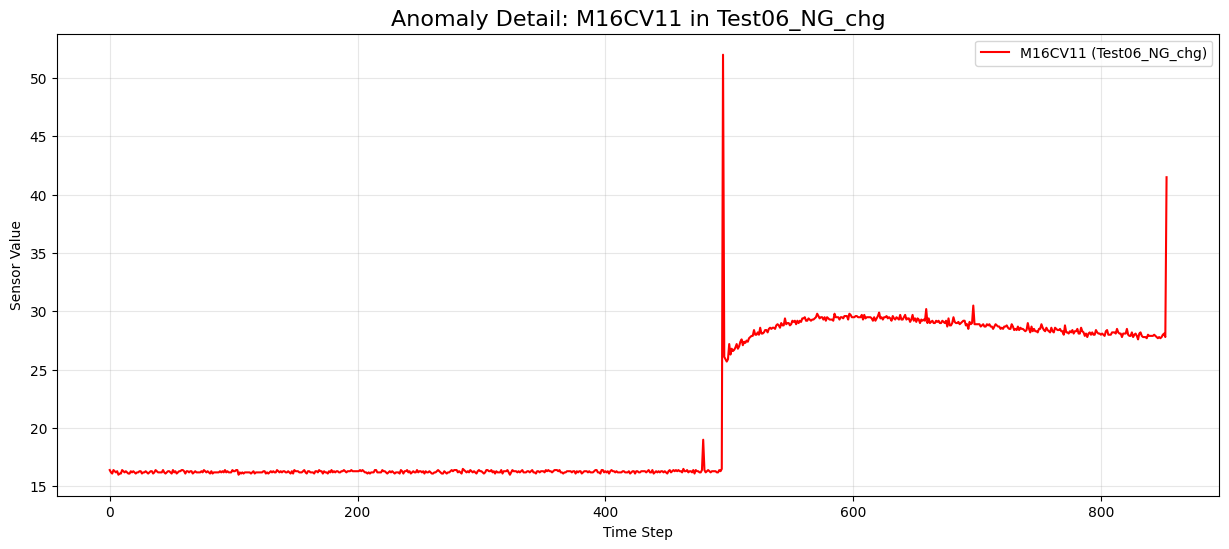

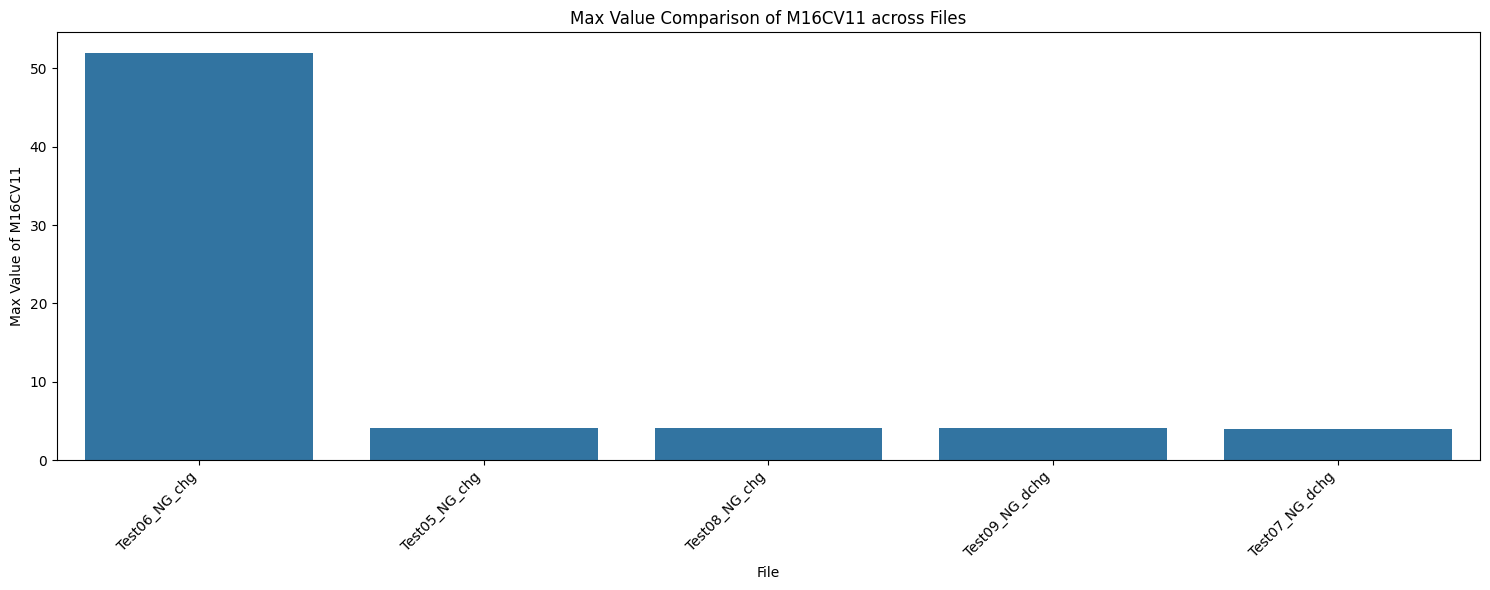

In [21]:
# Colab 셀 9: (수정) 특정 센서(M16CV11) 이상치 추적 및 시각화 (의존성 포함)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 0. (필수) 기본 변수 및 NG 파일 리스트 재정의 ---
# (이전 셀의 변수들이 메모리에 없을 경우를 대비해 다시 정의합니다)
BASE_PATH = "/content/drive/MyDrive/KAMP_Battery_Project"
TARGET_SENSOR = "M16CV11" # 범인 센서

# 분석할 NG 파일 리스트 자동 생성 (이 부분이 없어서 에러가 났었습니다)
NG_FILES_TO_ANALYZE = {}
print("분석할 NG 데이터 파일 검색 중...")

for i in range(1, 10): # Test01 ~ Test09
    num_str = f"{i:02d}"
    for type_str in ['chg', 'dchg']:
        file_name = f"Test{num_str}_NG_{type_str}.csv"
        data_path = os.path.join(BASE_PATH, "raw_data", "test", file_name)

        if os.path.exists(data_path):
            key_name = f"Test{num_str}_NG_{type_str}"
            NG_FILES_TO_ANALYZE[key_name] = {'data': data_path}

print(f"총 {len(NG_FILES_TO_ANALYZE)}개의 NG 파일을 찾았습니다.")


# --- 1. 이상치 추적 시작 ---
print(f"\n--- 🕵️‍♂️ '{TARGET_SENSOR}' 이상치 추적 시작 ---")

sensor_stats = []
all_sensor_data = {} # 그래프용 데이터 저장

# 모든 NG 파일 순회
for file_name, paths in NG_FILES_TO_ANALYZE.items():
    try:
        df = pd.read_csv(paths['data'])

        # 해당 센서 데이터가 있는지 확인
        if TARGET_SENSOR in df.columns:
            # 통계 계산
            max_val = df[TARGET_SENSOR].max()
            min_val = df[TARGET_SENSOR].min()
            mean_val = df[TARGET_SENSOR].mean()

            sensor_stats.append({
                'File': file_name,
                'Max_Value': max_val,
                'Min_Value': min_val,
                'Mean_Value': mean_val
            })

            all_sensor_data[file_name] = df[TARGET_SENSOR].values

    except Exception as e:
        print(f"Error reading {file_name}: {e}")

# 2. 통계 데이터프레임 생성 및 정렬 (최대값 기준)
if not sensor_stats:
    print("❌ 해당 센서를 포함하는 파일을 찾지 못했습니다.")
else:
    stats_df = pd.DataFrame(sensor_stats)
    sorted_df = stats_df.sort_values(by='Max_Value', ascending=False)

    print(f"\n--- 📊 '{TARGET_SENSOR}' 값이 가장 높은 파일 Top 5 ---")
    print(sorted_df.head(5).to_string(index=False))

    # 3. 범인 파일 시각화
    culprit_file = sorted_df.iloc[0]['File']
    culprit_max_val = sorted_df.iloc[0]['Max_Value']

    print(f"\n--- 🚨 범인 파일 검거: {culprit_file} (Max: {culprit_max_val:.4f}) ---")

    # Line Plot (범인 파일의 시계열 변화)
    plt.figure(figsize=(15, 6))
    plt.plot(all_sensor_data[culprit_file], label=f'{TARGET_SENSOR} ({culprit_file})', color='red')
    plt.title(f"Anomaly Detail: {TARGET_SENSOR} in {culprit_file}", fontsize=16)
    plt.xlabel("Time Step")
    plt.ylabel("Sensor Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # 4. (비교용) 다른 파일들과 함께 보기 (Bar Plot으로 변경 - Boxplot보다 직관적일 수 있음)
    plt.figure(figsize=(15, 6))
    sns.barplot(x='File', y='Max_Value', data=stats_df.sort_values(by='Max_Value', ascending=False))
    plt.title(f"Max Value Comparison of {TARGET_SENSOR} across Files")
    plt.xticks(rotation=45, ha='right') # X축 라벨 회전
    plt.ylabel(f"Max Value of {TARGET_SENSOR}")
    plt.tight_layout()
    plt.show()

--- 🕵️‍♂️ 추적 대상 핵심 센서 Top 4 (M16CV11 제외) ---
    Sensor  Defect_Correlation
1   M06T01            0.882328
2  M02CV01           -0.708708
3  M05CV10            0.599387
4  M01CV05           -0.436834
--------------------------------------------------

📡 분석 중: M06T01 (상관계수: 0.8823) -> 'max' 값 추적
  🚨 검거 완료! 범인 파일: [Test09_NG_dchg]
  🚨 이상 수치: 40.6000


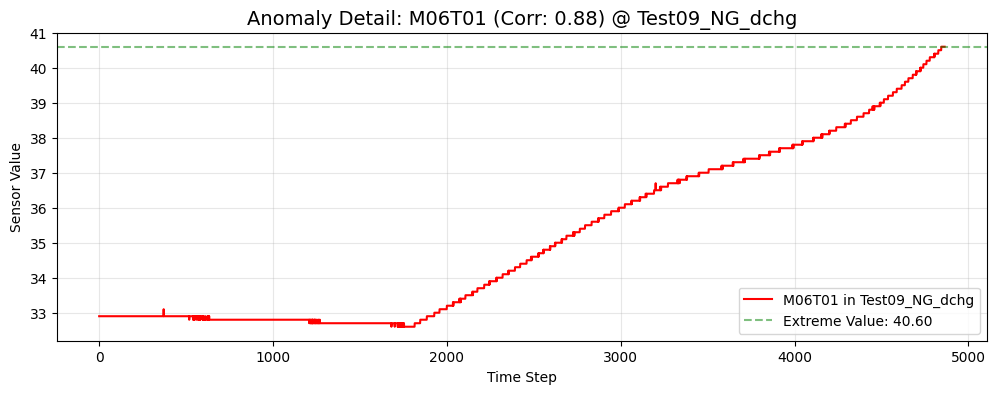


📡 분석 중: M02CV01 (상관계수: -0.7087) -> 'min' 값 추적
  🚨 검거 완료! 범인 파일: [Test07_NG_dchg]
  🚨 이상 수치: 3.1028


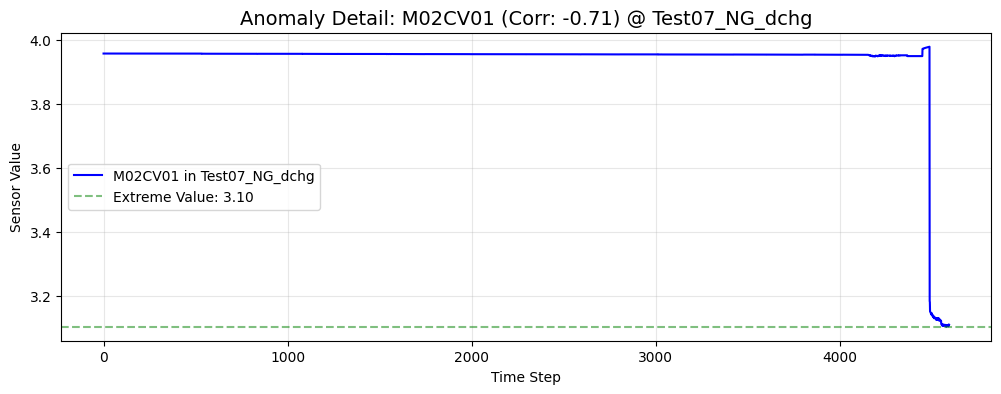


📡 분석 중: M05CV10 (상관계수: 0.5994) -> 'max' 값 추적
  🚨 검거 완료! 범인 파일: [Test05_NG_chg]
  🚨 이상 수치: 4.1126


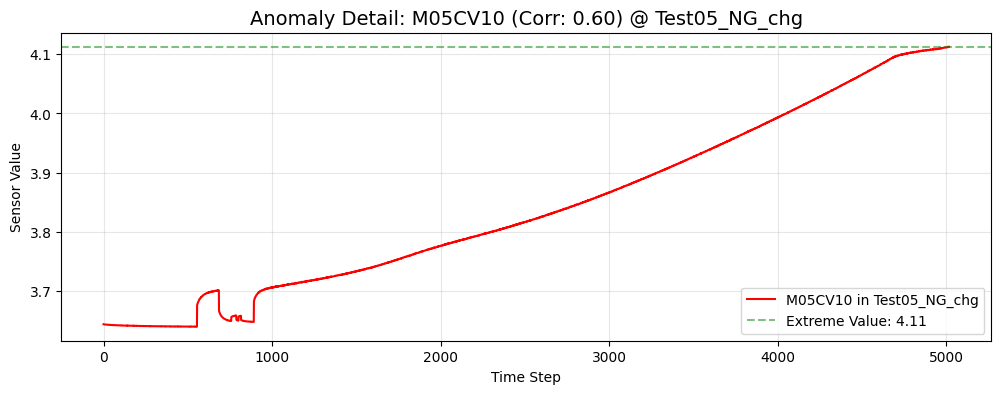


📡 분석 중: M01CV05 (상관계수: -0.4368) -> 'min' 값 추적
  🚨 검거 완료! 범인 파일: [Test09_NG_dchg]
  🚨 이상 수치: 3.3690


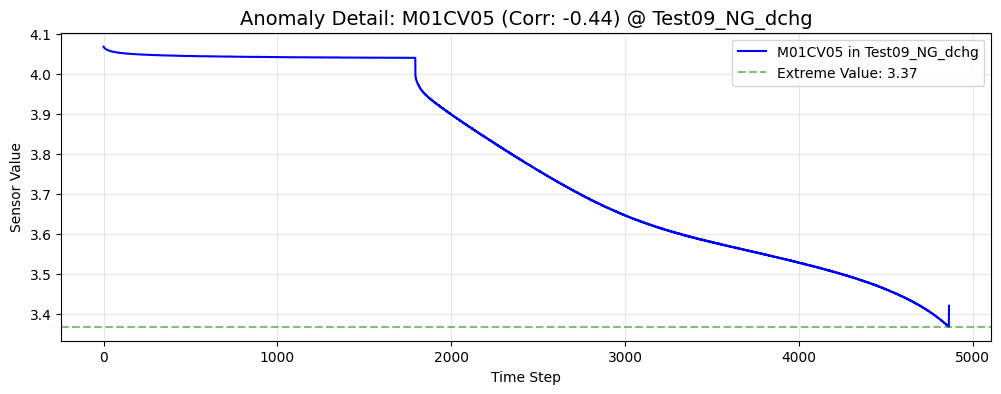

In [22]:
# Colab 셀 10: M16CV11을 제외한 Top 4 핵심 센서 추적 및 시각화

import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. 상관계수 파일 로드 및 Top 5 추출
CORR_CSV_PATH = "sensor_defect_correlation_all.csv" # (저장된 경로 확인 필요, 없다면 BASE_PATH 결합)
if not os.path.exists(CORR_CSV_PATH):
    CORR_CSV_PATH = os.path.join(BASE_PATH, "sensor_defect_correlation_all.csv")

corr_df = pd.read_csv(CORR_CSV_PATH)

# 'Impact_Magnitude' (절대값) 기준으로 정렬
corr_df['Impact_Magnitude'] = corr_df['Defect_Correlation'].abs()
sorted_df = corr_df.sort_values(by='Impact_Magnitude', ascending=False)

# M16CV11 제외하고 상위 4개 선택
target_sensors_df = sorted_df[sorted_df['Sensor'] != 'M16CV11'].head(4)
target_sensors = target_sensors_df['Sensor'].tolist()

print(f"--- 🕵️‍♂️ 추적 대상 핵심 센서 Top 4 (M16CV11 제외) ---")
print(target_sensors_df[['Sensor', 'Defect_Correlation']])
print("-" * 50)

# 2. 각 센서별 범인 파일 추적 및 시각화 루프
for sensor in target_sensors:
    # 상관계수 확인 (양수면 Max 추적, 음수면 Min 추적)
    correlation = target_sensors_df[target_sensors_df['Sensor'] == sensor]['Defect_Correlation'].values[0]
    find_mode = 'max' if correlation > 0 else 'min'

    print(f"\n📡 분석 중: {sensor} (상관계수: {correlation:.4f}) -> '{find_mode}' 값 추적")

    best_val = -99999 if find_mode == 'max' else 99999
    culprit_file = None
    culprit_data = None

    # 모든 NG 파일 순회
    for file_name, paths in NG_FILES_TO_ANALYZE.items():
        try:
            df = pd.read_csv(paths['data'])

            if sensor in df.columns:
                current_val = df[sensor].max() if find_mode == 'max' else df[sensor].min()

                # 범인 갱신 조건 (더 큰 Max거나, 더 작은 Min이면 갱신)
                update_condition = (current_val > best_val) if find_mode == 'max' else (current_val < best_val)

                if update_condition:
                    best_val = current_val
                    culprit_file = file_name
                    culprit_data = df[sensor].values

        except Exception as e:
            print(f"  Pass (Error): {file_name}")

    # 3. 결과 시각화
    if culprit_file:
        print(f"  🚨 검거 완료! 범인 파일: [{culprit_file}]")
        print(f"  🚨 이상 수치: {best_val:.4f}")

        plt.figure(figsize=(12, 4))
        plt.plot(culprit_data, label=f'{sensor} in {culprit_file}', color='red' if correlation > 0 else 'blue')
        plt.title(f"Anomaly Detail: {sensor} (Corr: {correlation:.2f}) @ {culprit_file}", fontsize=14)
        plt.xlabel("Time Step")
        plt.ylabel("Sensor Value")
        plt.axhline(y=best_val, color='green', linestyle='--', alpha=0.5, label=f'Extreme Value: {best_val:.2f}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print(f"  ❌ {sensor}를 포함한 파일을 찾지 못했습니다.")

In [23]:
# Colab 셀 11: (신규) 모든 NG 파일에 대한 불량 원인 자동 진단 및 리포트 생성

import pandas as pd
import numpy as np
import torch
import os

print("--- 🏥 배터리 불량 원인 자동 진단 시스템 가동 ---")

# 1. 진단 결과를 저장할 리스트
diagnosis_report = []

# 2. 정상 데이터의 통계값 (High/Low 판단 기준) 가져오기
# StandardScaler의 mean_ (평균)과 scale_ (표준편차)를 사용
train_mean = scaler.mean_
train_scale = scaler.scale_

# 3. 모든 NG 파일 순회
for file_name, paths in NG_FILES_TO_ANALYZE.items():
    try:
        # (1) 데이터 로드 및 전처리
        df = pd.read_csv(paths['data'])

        # 전처리 (Filter -> Impute -> Scale)
        data_filtered = df[FINAL_SENSOR_COLS]
        data_imputed = imputer.transform(data_filtered)
        data_scaled = scaler.transform(data_imputed)

        # Tensor 변환
        tensor_data = torch.FloatTensor(data_scaled).to(DEVICE)

        # (2) 모델 추론 (복원)
        with torch.no_grad():
            reconstructed = model(tensor_data)

        # (3) 센서별 에러 계산 (시간축 평균)
        # (Time, Sensors) -> (Sensors,) : 각 센서가 이 파일 전체에서 얼마나 이상했는지 평균냄
        sensor_errors = torch.mean((reconstructed - tensor_data)**2, dim=0).cpu().numpy()

        # (4) 가장 에러가 큰 '주범 센서' Top 1 찾기
        top_sensor_idx = np.argmax(sensor_errors)
        top_sensor_name = FINAL_SENSOR_COLS[top_sensor_idx]
        top_sensor_error = sensor_errors[top_sensor_idx]

        # (5) 주범 센서의 상태 판단 (High vs Low)
        # 해당 파일에서 주범 센서의 평균값 구하기 (Scaled 기준)
        file_sensor_mean = np.mean(data_scaled[:, top_sensor_idx])

        # 0보다 크면 평소보다 높은 것, 작으면 낮은 것 (StandardScaler 기준)
        status = "High" if file_sensor_mean > 0 else "Low"
        deviation = file_sensor_mean  # 얼마나 벗어났는지 (z-score 유사)

        # (6) 진단명 도출 (Rule-Based)
        diagnosis = "알 수 없음"
        if "CV" in top_sensor_name: # 전압 센서
            if status == "High":
                diagnosis = "⚠️ 과전압/과충전 (Overvoltage)"
            else:
                diagnosis = "📉 전압강하/용접불량 (Voltage Drop)"
        elif "T" in top_sensor_name: # 온도 센서
            if status == "High":
                diagnosis = "🔥 과열 (Overheating)"
            else:
                diagnosis = "❄️ 센서이상/냉각과다 (Sensor Error)"

        # (7) 리포트에 추가
        diagnosis_report.append({
            'File': file_name,
            'Culprit_Sensor': top_sensor_name,   # 주범 센서
            'Anomaly_Score': f"{top_sensor_error:.4f}", # 에러 크기
            'Value_Status': f"{status} ({deviation:.2f}σ)", # 상태 (높음/낮음)
            'AI_Diagnosis': diagnosis            # 최종 진단
        })

    except Exception as e:
        print(f"Error analyzing {file_name}: {e}")

# 4. 결과 데이터프레임 생성 및 출력
report_df = pd.DataFrame(diagnosis_report)

print("\n" + "="*80)
print("📋 AI 자동 불량 진단 리포트 (Total Diagnosis Report)")
print("="*80)
# 보기 좋게 출력
print(report_df.to_markdown(index=False))

# 5. CSV 저장
REPORT_SAVE_PATH = os.path.join(BASE_PATH, "AI_Diagnosis_Report.csv")
report_df.to_csv(REPORT_SAVE_PATH, index=False)
print(f"\n✅ 상세 진단 리포트가 저장되었습니다: {REPORT_SAVE_PATH}")

--- 🏥 배터리 불량 원인 자동 진단 시스템 가동 ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



📋 AI 자동 불량 진단 리포트 (Total Diagnosis Report)
| File           | Culprit_Sensor   |   Anomaly_Score | Value_Status   | AI_Diagnosis                        |
|:---------------|:-----------------|----------------:|:---------------|:------------------------------------|
| Test05_NG_chg  | M09T02           |          0.018  | Low (-1.64σ)   | ❄️ 센서이상/냉각과다 (Sensor Error) |
| Test06_NG_chg  | M16CV11          |       2836.94   | High (58.65σ)  | ⚠️ 과전압/과충전 (Overvoltage)      |
| Test07_NG_dchg | M09T01           |          0.0188 | Low (-2.43σ)   | ❄️ 센서이상/냉각과다 (Sensor Error) |
| Test08_NG_chg  | M16T02           |          0.0888 | Low (-0.44σ)   | ❄️ 센서이상/냉각과다 (Sensor Error) |
| Test09_NG_dchg | M16T02           |          0.0263 | High (1.23σ)   | 🔥 과열 (Overheating)               |

✅ 상세 진단 리포트가 저장되었습니다: /content/drive/MyDrive/KAMP_Battery_Project/AI_Diagnosis_Report.csv
